<a href="https://colab.research.google.com/github/Kirans1ngh/Machine-Learning-practice/blob/main/Classificstion/Classification_%26_Data_Imputation_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Results Table:
Imputer        Iterative       KNN    Simple
Dataset                                     
Breast Cancer   0.426888  0.519784  0.947316
Car Eval        0.988804  1.058517  0.988967
Diabetes        0.679567  0.819518  0.988758
House Pricing   1.007653  1.077026  1.006054


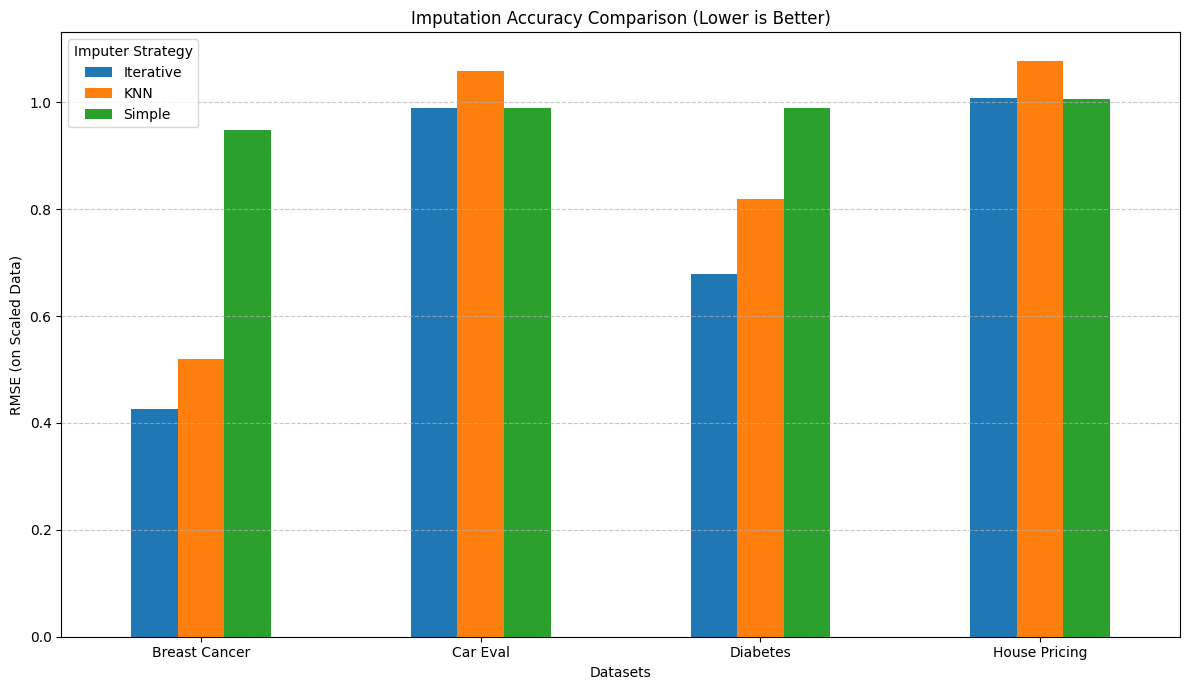

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer, load_diabetes
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Load Datasets
def get_data():
    bc = load_breast_cancer(as_frame=True).frame.iloc[:300, :10]
    db = load_diabetes(as_frame=True).frame.iloc[:300]

    # Simulating House Pricing
    hp = pd.DataFrame(np.random.rand(300, 5) * 100000, columns=['Size', 'Rooms', 'Age', 'Tax', 'Price'])

    # Simulating Car Evaluation (Numeric for imputation)
    car = pd.DataFrame({
        'price': np.random.choice([0, 1, 2], 300),
        'maint': np.random.choice([0, 1, 2], 300),
        'safety': np.random.choice([0, 1, 2], 300),
        'doors': np.random.choice([2, 4, 5], 300)
    })

    return {
        "Breast Cancer": bc,
        "Diabetes": db,
        "House Pricing": hp,
        "Car Eval": car
    }

# 2. Add Missing Values
def add_nan(df, pct=0.15):
    df_nan = df.copy().astype(float)
    mask = np.random.rand(*df_nan.shape) < pct
    df_nan[mask] = np.nan
    return df_nan, mask

# 3. Main Logic
datasets = get_data()
imputers = {
    "Simple": SimpleImputer(strategy='mean'),
    "KNN": KNNImputer(n_neighbors=5),
    "Iterative": IterativeImputer(max_iter=20, random_state=42)
}

results = []

for d_name, df in datasets.items():
    # Scale
    scaler = StandardScaler()
    df_sc = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

    # Induce NaN
    df_nan, mask = add_nan(df_sc)
    actuals = df_sc.values[mask]

    for i_name, imp in imputers.items():
        # Impute
        df_filled = imp.fit_transform(df_nan)
        preds = df_filled[mask]

        # Calculate RMSE
        rmse = np.sqrt(mean_squared_error(actuals, preds))
        results.append({"Dataset": d_name, "Imputer": i_name, "RMSE": rmse})

# Convert to DF for plotting
res_df = pd.pivot_table(pd.DataFrame(results), values='RMSE', index='Dataset', columns='Imputer')

# 4. Plotting
res_df.plot(kind='bar', figsize=(12, 7), rot=0)
plt.title("Imputation Accuracy Comparison (Lower is Better)")
plt.ylabel("RMSE (on Scaled Data)")
plt.xlabel("Datasets")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Imputer Strategy")
plt.tight_layout()
plt.savefig('imputation_comparison.png')

print("Results Table:")
print(res_df)